In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "true"

import torch
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.no_grad().__enter__()

print(f"Device: {device}")
print(device)

Device: cuda
cuda


In [ ]:
from analysis.load_model import *
import numpy as np
from xpmir.text.huggingface import HFTokenizer
from xpmir.neural.splade import MaxAggregation

## Random sampling, cosine similarities, repeat then average

Draw pairs of ids (avoid sampling from the same sentence multiple times), compute the cosine similarities between them at each layer, repeat multiple times and average

In [3]:
model_id = "distilbert/distilbert-base-uncased"

tokenizer = HFTokenizer.C(model_id=model_id)
aggregation = MaxAggregation.C()

In [ ]:
### Instantiate models

storage_folder = "~/sae_models/"

MODELS_PATH = {
    "baseline": f"{storage_folder}/splade_distil/normal_k=8/19c62889253d135ab4b0ed5dce54fd8e6ce98e61d96443f78750a9193785c881/model.pth",
    "sae_with_transform_head": f"{storage_folder}/normal_base/26c841d9f85b65bdb218df0e18e0a1ef439d07cc95cbe460689cf4640959d63b/model.pth",
    "sae_wo_transform_head_layer_6": f"{storage_folder}/normal_base/bb52be8203455b954fdacb45b23db38acc3f26f86e7b23fee6b67148632053fa/model.pth",
    "sae_wo_transform_head_layer_5": f"{storage_folder}/normal_base/554b89d2f3f34dfa16cecfd76a943eeaf7ac64b8982ceed99658f9e0d4cafb76/model.pth",
    "sae_wo_transform_head_layer_4": f"{storage_folder}/normal_base/dcadfa6d88341c63617e78ba34cd00a8ac502afaaf89a40ae4374c150372c66e/model.pth",
    "sae_wo_transform_head_layer_3": f"{storage_folder}/normal_base/343849fbe8960a2b5e372be8d801c9800cbdb11cd145886a1f831941db747a27/model.pth"
}

In [ ]:
from datamaestro import prepare_dataset
from xpmir.learning.base import Random
from xpmir.documents.samplers import RandomDocumentSampler
from tqdm import tqdm 

random = Random.C(seed=12)
documents = prepare_dataset("irds.msmarco-passage.documents")

# random text example
d_sampler=RandomDocumentSampler.C(
    documents=documents,
    max_count=100,
    random=random,
).instance()
_, doc_iter = d_sampler()
d_records = [record for record in doc_iter]

In [28]:
def compute_projection_head_reps(model, layer_outputs, device):
    vocab_layer_norm_outputs = []

    # Get the projection head components from baseline model
    vocab_transform = model.vocab_transform
    activation_fn = model.activation
    vocab_layer_norm = model.vocab_layer_norm
    vocab_projector = model.vocab_projector

    # Process baseline layer outputs through projection head
    # We need to reshape since data is already concatenated
    last_hidden = layer_outputs[-2]  # Last transformer layer output
    for i in range(last_hidden.shape[0]):
        hidden_state = torch.tensor(last_hidden[i:i+1]).to(device)
        
        # Step 1: vocab_transform (linear layer)
        transform_out = vocab_transform(hidden_state)
        
        # Step 2: activation function (GELU)
        activation_out = activation_fn(transform_out)
        
        # Step 3: layer normalization
        layer_norm_out = vocab_layer_norm(activation_out)
        vocab_layer_norm_outputs.append(layer_norm_out.detach().cpu().numpy())
        
        # Step 4: vocab_projector (final projection to vocabulary)
        # projector_out = vocab_projector(layer_norm_out)

    vocab_layer_norm_outputs = np.concatenate(vocab_layer_norm_outputs, axis=0)
    return vocab_layer_norm_outputs

In [10]:
from datamaestro_text.data.ir.base import TextItem
str_d_records = [record[TextItem].text for record in d_records]

In [ ]:
from transformers import AutoModelForMaskedLM, AutoTokenizer
from sklearn.metrics.pairwise import cosine_similarity

model = AutoModelForMaskedLM.from_pretrained(model_id)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model.to(device)
model.eval()

n_layer = model.config.num_hidden_layers

with torch.no_grad():
    batch_size = 25
    layer_outputs = [[] for _ in range(n_layer + 2)]  # 6 layers in DistilBERT + embedding + final output
    
    for i in tqdm(range(0, len(str_d_records), batch_size)):
        batch = str_d_records[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)
        output = model(**inputs, output_hidden_states=True)
        hidden_states = output.hidden_states
        final_value = output.logits

        for layer_idx, layer_hidden_state in enumerate(hidden_states):
            layer_outputs[layer_idx].append(np.concatenate(layer_hidden_state.cpu().numpy(), axis=0))
        layer_outputs[-1].append(np.concatenate(final_value.cpu().numpy(), axis=0))

for i in range(len(layer_outputs)):        
    layer_outputs[i] = np.concatenate(layer_outputs[i], axis=0)

layer_norm_outputs = compute_projection_head_reps(model, layer_outputs, device)

print("Computing cosine similarities...")
layer_similarities = [[] for _ in range(len(layer_outputs) + 2)] # Last index is dedicated to the transformation head if it exists

# Get the total number of vectors for sampling
total_vectors = layer_outputs[0].shape[0]

# Set random seed for reproducibility across models
np.random.seed(42)
nb_pairs = 1000

for i in range(nb_pairs):
    # Sample two random indices that are far apart (not in same document neighborhood)
    idx1 = np.random.randint(0, total_vectors)
    # Ensure idx2 is at least 256 positions away from idx1
    offset = 256
    valid_ranges = []
    if idx1 >= offset:
        valid_ranges.append((0, idx1 - offset))
    if idx1 + offset < total_vectors:
        valid_ranges.append((idx1 + offset, total_vectors))

    # Sample from valid ranges
    if valid_ranges:
        range_choice = np.random.choice(len(valid_ranges))
        start, end = valid_ranges[range_choice]
        idx2 = np.random.randint(start, end)
    else:
        continue  # Skip if no valid range exists

    # Compute cosine similarity between the two sampled vectors
    for layer_idx in range(len(layer_outputs)):
        vec1 = layer_outputs[layer_idx].reshape(-1, layer_outputs[layer_idx].shape[-1])[idx1]
        vec2 = layer_outputs[layer_idx].reshape(-1, layer_outputs[layer_idx].shape[-1])[idx2]
        layer_similarities[layer_idx].append(cosine_similarity([vec1], [vec2])[0, 0])

        vec1 = layer_norm_outputs.reshape(-1, layer_norm_outputs.shape[-1])[idx1]
        vec2 = layer_norm_outputs.reshape(-1, layer_norm_outputs.shape[-1])[idx2]
        layer_similarities[-1].append(cosine_similarity([vec1], [vec2])[0, 0])
    
# Compute mean and std for each layer
print("Pretrained DistilBERT - Layer similarities:")
results = []
for layer_idx in range(len(layer_similarities)):
    mean_sim = np.mean(layer_similarities[layer_idx])
    std_sim = np.std(layer_similarities[layer_idx])
    print(f"  Layer {layer_idx}: Mean = {mean_sim:.4f}, Std = {std_sim:.4f}")


In [ ]:
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import gc

nb_pairs = 1000

# Dictionary to store results for all models
all_results = {}

for model_name, model_path in MODELS_PATH.items():
    print(f"\n{'='*60}")
    print(f"Processing model: {model_name}")
    print(f"{'='*60}")
    
    # Determine which loading function to use
    if model_name == "baseline":
        model = load_baseline(model_path, k=8, device=device)
        has_transform_head = True
        n_layer = 6
    elif "sae_with_transform_head" in model_name:
        model = load_sae_with_transform_head(model_path, k=8, sae_width=65536, override_k=8, dead_steps_threshold=10_000_000, device=device)
        has_transform_head = True
        n_layer = 6
    else:  # without transform head
        last_char = model_name[-1]
        layer = int(last_char) if last_char.isdigit() else -1
        model = load_sae_without_transform_head(model_path, k=8, sae_width=65536, override_k=8, dead_steps_threshold=10_000_000, layer=layer, device=device)
        has_transform_head = False
        n_layer = int(last_char)
    
    # Compute layer outputs
    print("Computing layer outputs...")
    with torch.no_grad():
        batch_size = 25
        layer_outputs = [[] for _ in range(n_layer + 2)]  # 6 layers in DistilBERT + embedding + final output
        
        for i in tqdm(range(0, len(d_records), batch_size)):
            batch = d_records[i:i+batch_size]
            output = model.encode_documents(batch)
            hidden_states = output.hidden_states
            final_value = output.value

            for layer_idx, layer_hidden_state in enumerate(hidden_states):
                layer_outputs[layer_idx].append(np.concatenate(layer_hidden_state.cpu().numpy(), axis=0))
            layer_outputs[-1].append(np.concatenate(final_value.cpu().numpy(), axis=0))

        for i in range(len(layer_outputs)):        
            layer_outputs[i] = np.concatenate(layer_outputs[i], axis=0)
    
    # Compute the internal detail of the transformation head (if it exists)
    if has_transform_head:
        if model_name == "baseline":
            layer_norm_outputs = compute_projection_head_reps(model.encoder.encoder.model, layer_outputs, device)
        else: # SAE with Transform head
            layer_norm_outputs = compute_projection_head_reps(model.encoder.encoder.model.model.model, layer_outputs, device)
            
    # Compute similarities using random sampling
    print("Computing cosine similarities...")
    layer_similarities = [[] for _ in range(len(layer_outputs) + 1)] # Last index is dedicated to the transformation head if it exists
    
    # Get the total number of vectors for sampling
    total_vectors = layer_outputs[0].shape[0]
    
    # Set random seed for reproducibility across models
    np.random.seed(42)
    
    for i in range(nb_pairs):
        # Sample two random indices that are far apart (not in same document neighborhood)
        idx1 = np.random.randint(0, total_vectors)
        # Ensure idx2 is at least 256 positions away from idx1
        offset = 256
        valid_ranges = []
        if idx1 >= offset:
            valid_ranges.append((0, idx1 - offset))
        if idx1 + offset < total_vectors:
            valid_ranges.append((idx1 + offset, total_vectors))

        # Sample from valid ranges
        if valid_ranges:
            range_choice = np.random.choice(len(valid_ranges))
            start, end = valid_ranges[range_choice]
            idx2 = np.random.randint(start, end)
        else:
            continue  # Skip if no valid range exists

        # Compute cosine similarity between the two sampled vectors
        for layer_idx in range(len(layer_outputs)):
            vec1 = layer_outputs[layer_idx].reshape(-1, layer_outputs[layer_idx].shape[-1])[idx1]
            vec2 = layer_outputs[layer_idx].reshape(-1, layer_outputs[layer_idx].shape[-1])[idx2]
            layer_similarities[layer_idx].append(cosine_similarity([vec1], [vec2])[0, 0])

        if has_transform_head:
            vec1 = layer_norm_outputs.reshape(-1, layer_norm_outputs.shape[-1])[idx1]
            vec2 = layer_norm_outputs.reshape(-1, layer_norm_outputs.shape[-1])[idx2]
            layer_similarities[-1].append(cosine_similarity([vec1], [vec2])[0, 0])
    
    # Compute mean and std for each layer
    print(f"\n{model_name} - Layer similarities:")
    results = []
    for layer_idx in range(len(layer_similarities)):
        mean_sim = np.mean(layer_similarities[layer_idx])
        std_sim = np.std(layer_similarities[layer_idx])
        print(f"  Layer {layer_idx}: Mean = {mean_sim:.4f}, Std = {std_sim:.4f}")
        results.append({
            'model': model_name,
            'layer': layer_idx,
            'mean_similarity': mean_sim,
            'std_similarity': std_sim,
            'has_transform_head': has_transform_head
        })
    
    # Store results
    all_results[model_name] = results
    
    # Save intermediate results to CSV
    df = pd.DataFrame(results)
    csv_filename = f"anisotropy_similarities_{model_name}.csv"
    df.to_csv(csv_filename, index=False)
    print(f"Saved results to {csv_filename}")
    
    # Clean up memory
    del model
    del layer_outputs
    del layer_similarities
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Memory cleaned up for {model_name}")

# Create a combined DataFrame with all results
print("\n" + "="*60)
print("Creating combined results file...")
all_results_list = []
for model_name, results in all_results.items():
    all_results_list.extend(results)

combined_df = pd.DataFrame(all_results_list)
combined_df.to_csv("anisotropy_similarities_all_models.csv", index=False)
print("Saved combined results to anisotropy_similarities_all_models.csv")

# Display summary
print("\nSummary:")
print(combined_df.groupby('model').agg({'mean_similarity': ['mean', 'std']}))

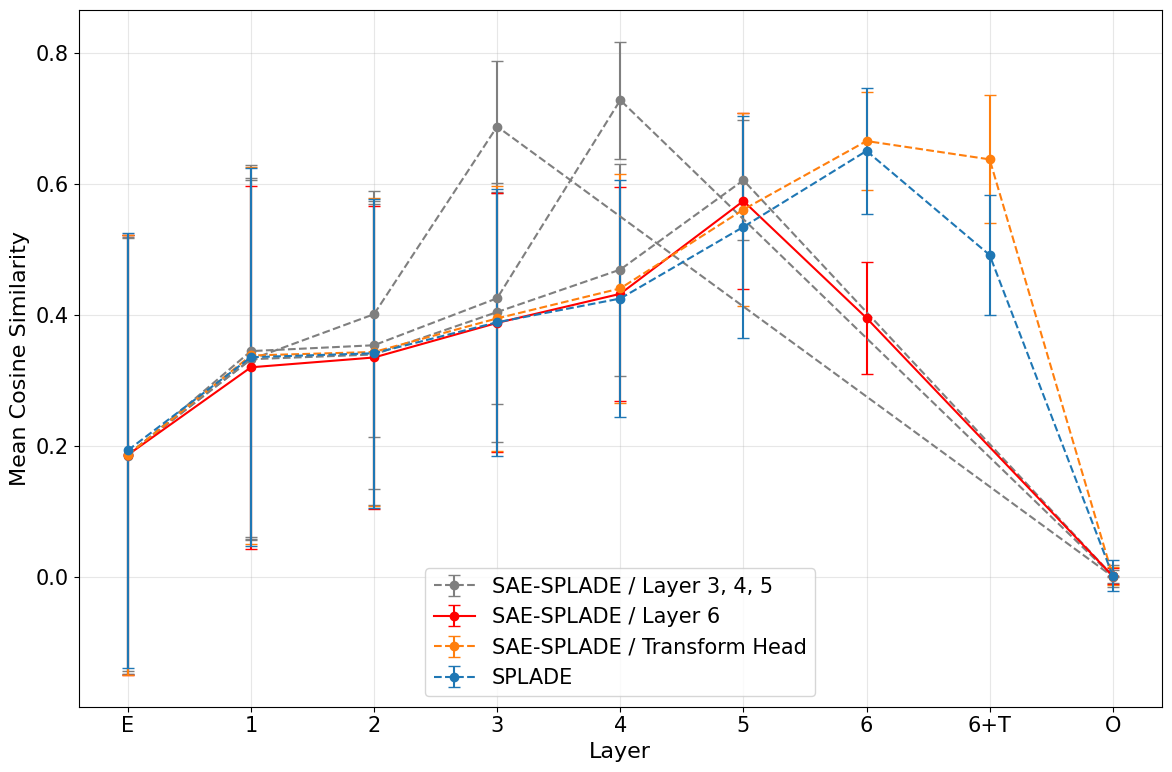

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15
})

# Load combined results (adjust path if needed)
df = pd.read_csv('anisotropy_similarities_all_models.csv')

df['model'] = df['model'].replace({'sae_wo_transform_head_layer_3': 'SAE-SPLADE / Layer 3',
                                   'sae_wo_transform_head_layer_4': 'SAE-SPLADE / Layer 4',
                                   'sae_wo_transform_head_layer_5': 'SAE-SPLADE / Layer 5',
                                   'sae_wo_transform_head_layer_6': 'SAE-SPLADE / Layer 6',
                                   'baseline': 'SPLADE',
                                   'sae_with_transform_head': 'SAE-SPLADE / Transform Head'})

# Fixed x-labels as requested
labels = ["E", "1", "2", "3", "4", "5", "6", "6+T", "O"]
label_to_x = {lab: i for i, lab in enumerate(labels)}
x_to_label = {str(i): lab for i, lab in enumerate(labels)}
x_positions = list(range(len(labels)))

plt.figure(figsize=(12, 8))
models = sorted(df['model'].unique())
# We'll group SAE Layer 3/4/5 into a single legend entry (grey), keep Layer 6 as red
group_colors = {
    'SAE-SPLADE / Layer 3, 4, 5': '#7f7f7f',  # grey
    'SAE-SPLADE / Layer 6': 'red',
    'SPLADE': 'C0',
    'SAE-SPLADE / Transform Head': 'C1'
}
plotted_groups = set()
for model in models:
    mdf = df[df['model'] == model]
    # prepare y and yerr arrays filled with NaN
    y = np.full(len(labels), np.nan, dtype=float)
    yerr = np.full(len(labels), np.nan, dtype=float)
    last_non_nan_index = 0
    for _, row in mdf.iterrows():
        layer_label = str(row['layer'])
        y[int(layer_label)] = row.get('mean_similarity', np.nan)
        yerr[int(layer_label)] = row.get('std_similarity', np.nan)
        if not np.isnan(y[int(layer_label)]):
            last_non_nan_index = int(layer_label)
    # plot only valid points to avoid connecting across missing values
    if np.isnan(y[-1]):
        y[-1] = y[last_non_nan_index]
        yerr[-1] = yerr[last_non_nan_index]
        y[last_non_nan_index] = np.nan
        yerr[last_non_nan_index] = np.nan

    if mdf['has_transform_head'].iloc[0] == True:
        # For model with a transform head, its similarity is in the last position, while it should be in -2 (6+T)
        tmp_y = y[-1]
        tmp_y_err = yerr[-1]
        y[-1] = y[-2]
        yerr[-1] = yerr[-2]
        y[-2] = tmp_y
        yerr[-2] = tmp_y_err

    valid_idx = np.where(~np.isnan(y))[0]
    if len(valid_idx) == 0:
        continue
    # Determine plotting group and color
    if model.startswith('SAE-SPLADE / Layer') and any(seg in model for seg in ['Layer 3', 'Layer 4', 'Layer 5']):
        group_label = 'SAE-SPLADE / Layer 3, 4, 5'
        color = group_colors[group_label]
    elif model == 'SAE-SPLADE / Layer 6':
        group_label = 'SAE-SPLADE / Layer 6'
        color = group_colors[group_label]
    else:
        group_label = model
        color = group_colors.get(model, None)

    # Only label the first plotted member of a group so the legend shows one line per group
    label_to_use = group_label if group_label not in plotted_groups else None
    # hashed/dashed lines for all except SAE-SPLADE / Layer 6
    linestyle = '-' if group_label == 'SAE-SPLADE / Layer 6' else "--"
    plt.errorbar(valid_idx, y[valid_idx], yerr=yerr[valid_idx], marker='o', linestyle=linestyle, capsize=4, label=label_to_use, color=color)
    if label_to_use:
        plotted_groups.add(group_label)

plt.xticks(x_positions, labels)
plt.xlabel('Layer')
plt.ylabel('Mean Cosine Similarity')
# plt.title('Per-model Mean Cosine Similarity across Layers')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig("~/tree_colbert/Results/anisotropy_analysis_reworked.png", dpi=300)
plt.show()